# 🔧 Feature Engineering on the MPG Dataset

**Feature engineering** is the process of creating, transforming, or selecting input features from raw data to improve a machine learning model's performance. Good features help models capture meaningful patterns and lead to better predictions.

---

## 📋 What We'll Cover

| # | Technique | Description |
|---|-----------|-------------|
| 1 | **Setup & EDA** | Load data, inspect shape, missing values, distributions |
| 2 | **Derived Features** | Power-to-weight ratio, displacement per cylinder |
| 3 | **Binning** | Weight categories (uniform), horsepower bins (quantile) |
| 4 | **Temporal Features** | Car age from model year |
| 5 | **Text / NLP Features** | Extract brand from car name |
| 6 | **Aggregate / Target Encoding** | Brand-average MPG, brand popularity |
| 7 | **Interaction Features** | Cross-products between numeric columns |
| 8 | **Log Transformation** | Normalize skewed distributions |
| 9 | **One-Hot Encoding** | Encode categorical variables for ML |
| 10 | **Correlation Analysis** | Which engineered features matter most? |
| 11 | **Feature Summary** | Final DataFrame overview |

---


## 1. 📦 Imports & Global Style

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4)})

print("Libraries loaded ✅")

Libraries loaded ✅


## 2. 📂 Load the MPG Dataset

We use **`seaborn.load_dataset('mpg')`** — no CSV needed.  
The dataset contains fuel-efficiency data for 398 cars from 1970–1982.


In [2]:
df_raw = sns.load_dataset("mpg")
df = df_raw.copy()

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Shape: (398, 9)
Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [3]:
print("\n── Data Types ──")
print(df.dtypes)

print("\n── Missing Values ──")
print(df.isnull().sum())



── Data Types ──
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

── Missing Values ──
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [4]:
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## 3. 🔍 Exploratory Data Analysis

Quick visual survey before engineering any features.


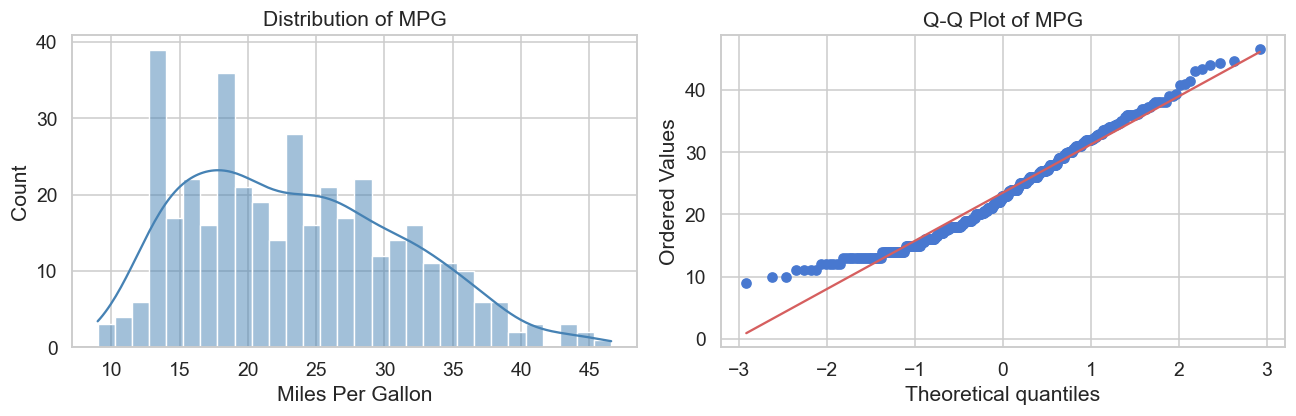

In [5]:
# Distribution of the target variable: MPG
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["mpg"].dropna(), kde=True, ax=axes[0], color="steelblue", bins=30)
axes[0].set_title("Distribution of MPG")
axes[0].set_xlabel("Miles Per Gallon")

stats.probplot(df["mpg"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of MPG")

plt.tight_layout()
plt.show()


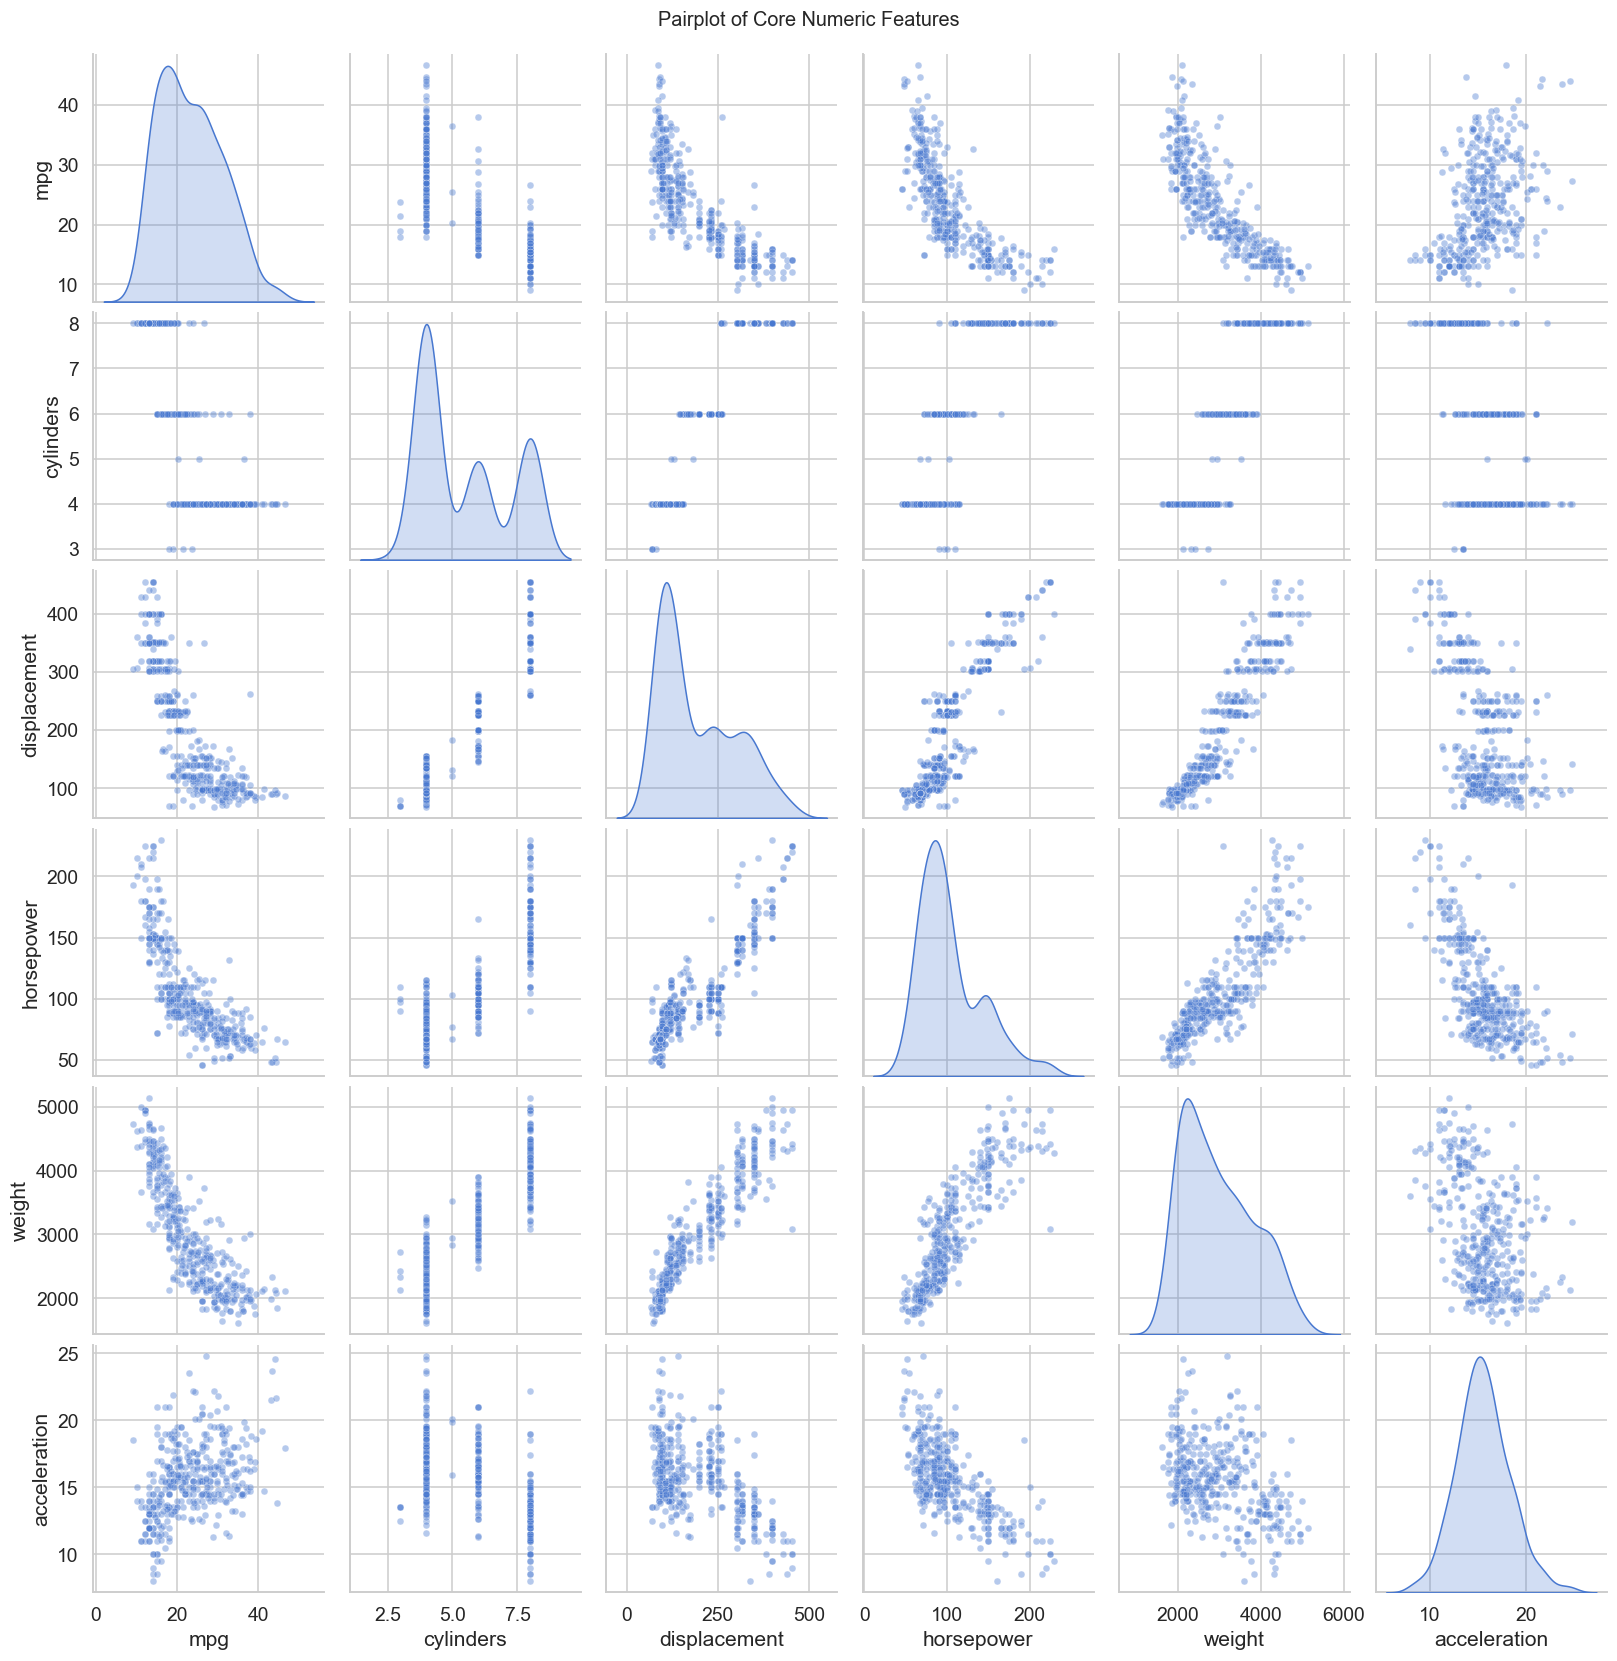

In [6]:
# Pairplot of core numeric features
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]
df_num = df[numeric_cols].dropna()

g = sns.pairplot(df_num, diag_kind="kde", plot_kws={"alpha": 0.4, "s": 20},
                 diag_kws={"fill": True})
g.figure.suptitle("Pairplot of Core Numeric Features", y=1.01, fontsize=13)
plt.show()


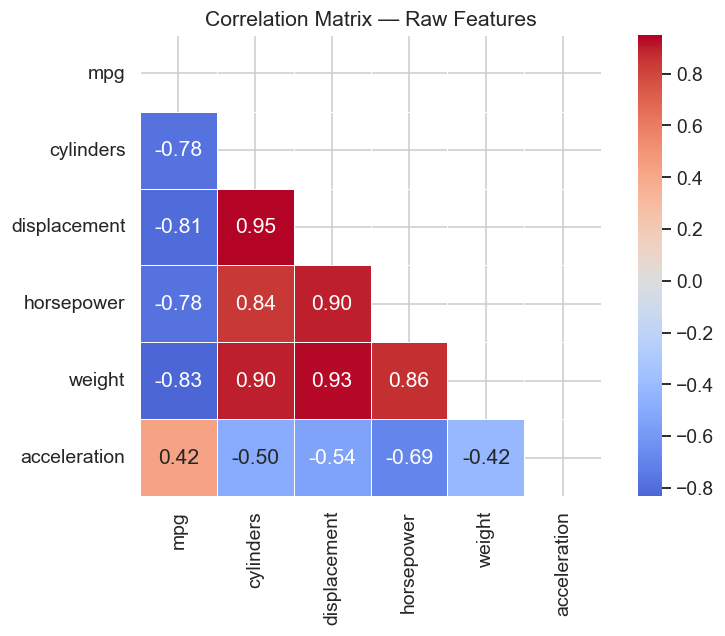

In [7]:
# Correlation heatmap (raw features only)
plt.figure(figsize=(8, 6))
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Correlation Matrix — Raw Features")
plt.tight_layout()
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_8428\4132659923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="origin", y="mpg", palette="Set2", inner="box")


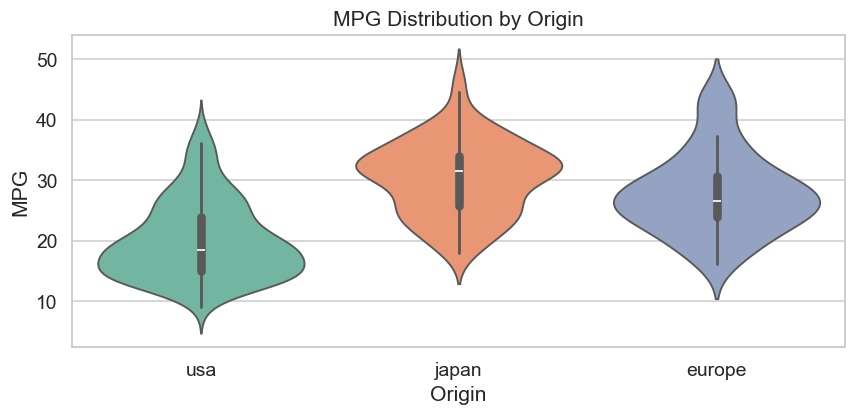

In [8]:
# MPG by Origin — violin plot
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x="origin", y="mpg", palette="Set2", inner="box")
plt.title("MPG Distribution by Origin")
plt.xlabel("Origin")
plt.ylabel("MPG")
plt.tight_layout()
plt.show()


## 4. 🧹 Handle Missing Values

Before engineering features we must handle `NaN`s — otherwise derived columns inherit them.


In [9]:
# 'horsepower' has 6 missing values — fill with median (robust to outliers)
hp_median = df["horsepower"].median()
df["horsepower"] = df["horsepower"].fillna(hp_median)

print(f"Horsepower missing after fill: {df['horsepower'].isnull().sum()}")
print(f"Median used for imputation: {hp_median}")


Horsepower missing after fill: 0
Median used for imputation: 93.5


## 5. ⚙️ Derived / Ratio Features

Combining existing columns often captures physics-based relationships the model wouldn't discover on its own.


In [10]:
# 5a. Power-to-Weight Ratio
df["power_to_weight"] = df["horsepower"] / df["weight"]

# 5b. Displacement per Cylinder
df["displacement_per_cyl"] = df["displacement"] / df["cylinders"]

# 5c. Acceleration-to-Weight Ratio (handling ability proxy)
df["accel_to_weight"] = df["acceleration"] / df["weight"]

print(df[["horsepower", "weight", "power_to_weight",
          "displacement", "cylinders", "displacement_per_cyl",
          "acceleration", "accel_to_weight"]].head(6))


   horsepower  weight  power_to_weight  displacement  cylinders  \
0       130.0    3504         0.037100         307.0          8   
1       165.0    3693         0.044679         350.0          8   
2       150.0    3436         0.043655         318.0          8   
3       150.0    3433         0.043694         304.0          8   
4       140.0    3449         0.040591         302.0          8   
5       198.0    4341         0.045612         429.0          8   

   displacement_per_cyl  acceleration  accel_to_weight  
0                38.375          12.0         0.003425  
1                43.750          11.5         0.003114  
2                39.750          11.0         0.003201  
3                38.000          12.0         0.003495  
4                37.750          10.5         0.003044  
5                53.625          10.0         0.002304  


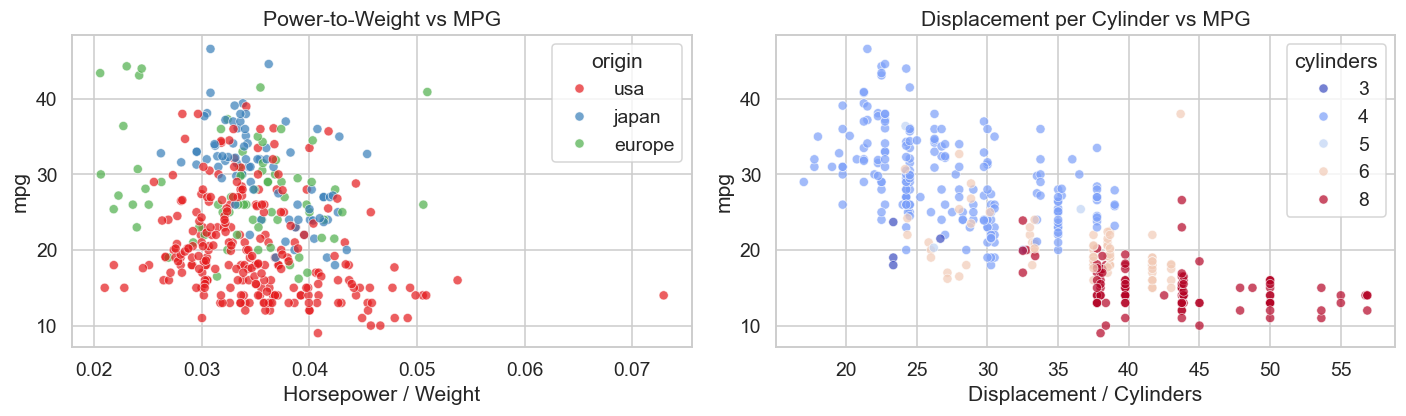

In [11]:
# Visualise: Power-to-Weight vs MPG
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(data=df, x="power_to_weight", y="mpg", hue="origin",
                alpha=0.7, ax=axes[0], palette="Set1")
axes[0].set_title("Power-to-Weight vs MPG")
axes[0].set_xlabel("Horsepower / Weight")

sns.scatterplot(data=df, x="displacement_per_cyl", y="mpg", hue="cylinders",
                palette="coolwarm", alpha=0.7, ax=axes[1], legend="full")
axes[1].set_title("Displacement per Cylinder vs MPG")
axes[1].set_xlabel("Displacement / Cylinders")

plt.tight_layout()
plt.show()


## 6. 📊 Binning (Discretisation)

Converting continuous variables into ordered categories can help tree-based models and reveal non-linear trends.

### 6a. Weight Categories — Uniform Bins
- Here weight range from 1613 to 5140
- Here I am creating a categorical column from numerical column


In [33]:
# step0: print weight

print(sorted(df['weight'].to_list()))

[1613, 1649, 1755, 1760, 1773, 1795, 1795, 1800, 1800, 1825, 1825, 1834, 1835, 1835, 1836, 1845, 1850, 1867, 1875, 1915, 1925, 1937, 1937, 1940, 1945, 1950, 1950, 1955, 1963, 1965, 1965, 1968, 1970, 1975, 1975, 1980, 1985, 1985, 1985, 1985, 1990, 1990, 1995, 2000, 2003, 2019, 2020, 2025, 2035, 2045, 2045, 2046, 2050, 2051, 2065, 2065, 2070, 2074, 2075, 2085, 2100, 2108, 2110, 2110, 2120, 2123, 2124, 2125, 2125, 2125, 2126, 2130, 2130, 2130, 2130, 2135, 2144, 2145, 2150, 2155, 2155, 2155, 2158, 2160, 2164, 2164, 2171, 2188, 2189, 2190, 2190, 2200, 2202, 2205, 2210, 2215, 2219, 2220, 2220, 2223, 2226, 2228, 2230, 2234, 2245, 2246, 2254, 2255, 2264, 2265, 2265, 2265, 2278, 2279, 2288, 2290, 2295, 2300, 2300, 2300, 2310, 2320, 2330, 2335, 2350, 2370, 2372, 2375, 2379, 2380, 2385, 2391, 2395, 2395, 2401, 2405, 2408, 2408, 2420, 2430, 2434, 2451, 2464, 2472, 2489, 2490, 2500, 2506, 2511, 2515, 2525, 2542, 2542, 2545, 2556, 2560, 2565, 2572, 2575, 2582, 2585, 2587, 2592, 2595, 2600, 2605, 261

### Define bins:
-  light : 0 - 2000
-  medium: 2000 - 3000
-  heavy: 3000 - 5200

In [34]:
weight_bins   = [0, 2000, 3000, 5200]
weight_labels = ["light", "medium", "heavy"]

df["weight_category"] = pd.cut(df["weight"], 
                               bins=weight_bins, 
                               labels=weight_labels
)

print(df[['weight', 'weight_category']].sample(10))


     weight weight_category
393    2790          medium
102    1950           light
244    1985           light
27     4382           heavy
343    1755           light
91     4464           heavy
312    2019          medium
155    3158           heavy
359    3230           heavy
214    3870           heavy


In [35]:
print("── Value Counts ──")
print(df["weight_category"].value_counts())

── Value Counts ──
weight_category
medium    186
heavy     168
light      44
Name: count, dtype: int64


In [36]:
print("── Mean MPG by Weight Category ──")
print(df.groupby("weight_category", observed=True)["mpg"].mean().round(2))

# observ: MPG decreases as we move from light → heavy
# Binning reveals trends clearly

── Mean MPG by Weight Category ──
weight_category
light     33.16
medium    27.25
heavy     16.85
Name: mpg, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_8428\2467706941.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="weight_category", y="mpg",
C:\Users\hi\AppData\Local\Temp\ipykernel_8428\2467706941.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="weight_category", order=["light", "medium", "heavy"],


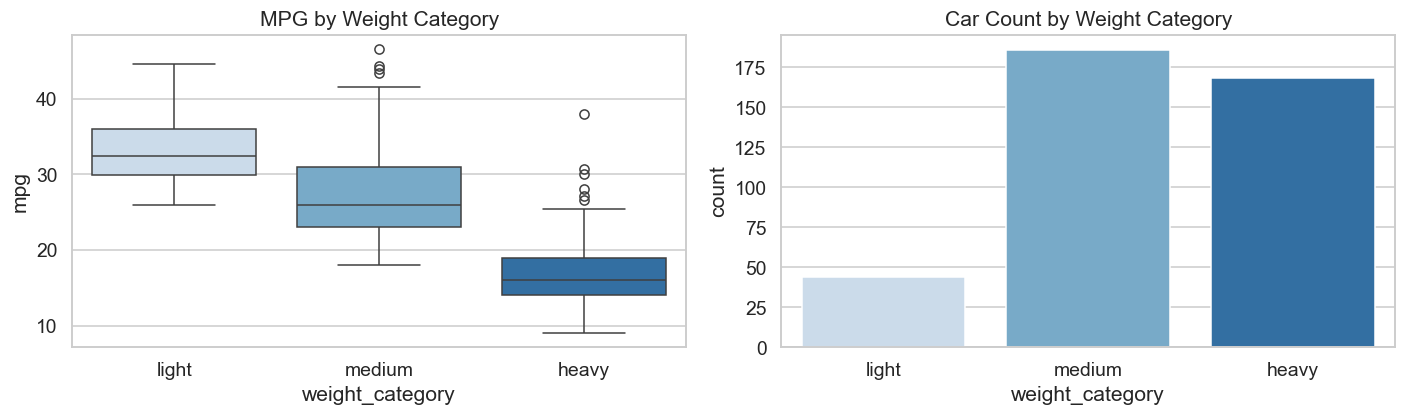

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x="weight_category", y="mpg",
            order=["light", "medium", "heavy"], palette="Blues", ax=axes[0])
axes[0].set_title("MPG by Weight Category")

sns.countplot(data=df, x="weight_category", order=["light", "medium", "heavy"],
              palette="Blues", ax=axes[1])
axes[1].set_title("Car Count by Weight Category")

plt.tight_layout()
plt.show()


### 6b. Horsepower Bins — Quantile (Equal-Frequency)

In [37]:
# step1: create 3 equal frequency bins
df["horsepower_bin"] = pd.qcut(df["horsepower"], 
                               q=3, 
                               labels=["low", "medium", "high"]
)
print(df[['horsepower', 'horsepower_bin']].sample(10))


     horsepower horsepower_bin
228        98.0         medium
107       100.0         medium
394        52.0            low
214       130.0           high
123       122.0           high
165       110.0         medium
206        72.0            low
186        83.0            low
267        95.0         medium
58         80.0            low


In [39]:
print("── Value Counts ──")
print(df["horsepower_bin"].value_counts())

── Value Counts ──
horsepower_bin
low       141
medium    141
high      116
Name: count, dtype: int64


In [40]:
print("── Mean MPG by Horsepower Bin ──")
print(df.groupby("horsepower_bin", observed=True)["mpg"].mean().round(2))

# observation:
# As HP go from low to high, the mean mpg decreases

── Mean MPG by Horsepower Bin ──
horsepower_bin
low       30.66
medium    22.73
high      15.78
Name: mpg, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_8428\3713808127.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="horsepower_bin", y="mpg",
C:\Users\hi\AppData\Local\Temp\ipykernel_8428\3713808127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="horsepower_bin", y="mpg", order=["low", "medium", "high"],


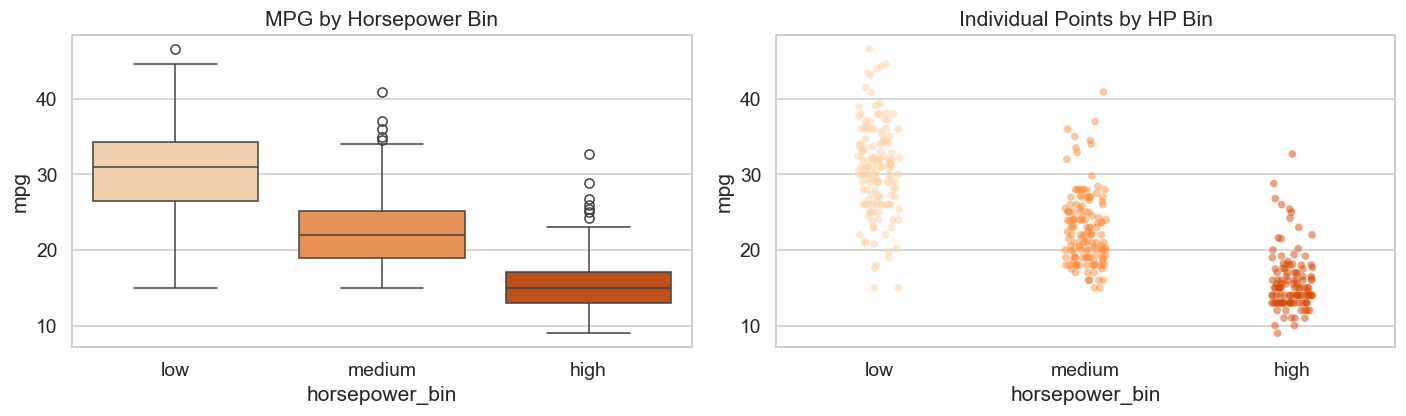

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x="horsepower_bin", y="mpg",
            order=["low", "medium", "high"], palette="Oranges", ax=axes[0])
axes[0].set_title("MPG by Horsepower Bin")

sns.stripplot(data=df, x="horsepower_bin", y="mpg", order=["low", "medium", "high"],
              palette="Oranges", alpha=0.5, jitter=True, ax=axes[1])
axes[1].set_title("Individual Points by HP Bin")

plt.tight_layout()
plt.show()


## 7. 🕐 Temporal Feature — Car Age
- Concept: Time-based feature engineering

`model_year` is a 2-digit year (70–82).  
We derive **`car_age`** as the distance from the newest model year in the dataset.
```
car_age = model_year_max_value - model_year
```


In [16]:
max_year = df["model_year"].max()
df["car_age"] = max_year - df["model_year"]

print(f"Max model year in dataset: {max_year}")
print()
print(df[["model_year", "car_age", "mpg"]].sample(10, random_state=42))


Max model year in dataset: 82

     model_year  car_age   mpg
198          76        6  33.0
396          82        0  28.0
33           71       11  19.0
208          76        6  13.0
93           73        9  14.0
84           72       10  27.0
373          82        0  24.0
94           73        9  13.0
222          77        5  17.0
126          74        8  21.0


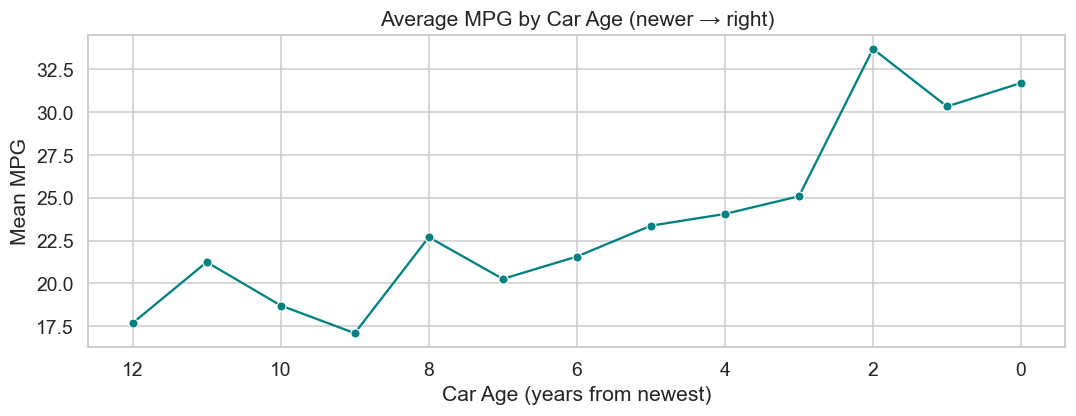

In [17]:
# Trend: car_age vs MPG — newer cars tend to be more efficient
plt.figure(figsize=(10, 4))
age_mpg = df.groupby("car_age")["mpg"].mean().reset_index()
sns.lineplot(data=age_mpg, x="car_age", y="mpg", marker="o", color="teal")
plt.gca().invert_xaxis()          # newest cars on the right
plt.title("Average MPG by Car Age (newer → right)")
plt.xlabel("Car Age (years from newest)")
plt.ylabel("Mean MPG")
plt.tight_layout()
plt.show()


## 8. 🔤 Text Feature — Extract Brand from Car Name

The `name` column contains entries like *"ford escort 2h"*.  
Splitting on whitespace and taking the first token gives us the **brand**.


In [18]:
df["brand"] = df["name"].str.split().str[0].str.lower()

# Normalise a few misspellings / variants
brand_map = {
    "chevroelt": "chevrolet",
    "chevy":     "chevrolet",
    "maxda":     "mazda",
    "toyouta":   "toyota",
    "vokswagen": "volkswagen",
    "vw":        "volkswagen",
}
df["brand"] = df["brand"].replace(brand_map)

print(df["brand"].value_counts())


brand
ford             51
chevrolet        47
plymouth         31
dodge            28
amc              28
toyota           26
datsun           23
volkswagen       22
buick            17
pontiac          16
honda            13
mazda            12
mercury          11
oldsmobile       10
peugeot           8
fiat              8
audi              7
chrysler          6
volvo             6
renault           5
opel              4
saab              4
subaru            4
mercedes-benz     2
bmw               2
cadillac          2
hi                1
capri             1
mercedes          1
triumph           1
nissan            1
Name: count, dtype: int64


C:\Users\hi\AppData\Local\Temp\ipykernel_8428\1691136544.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")


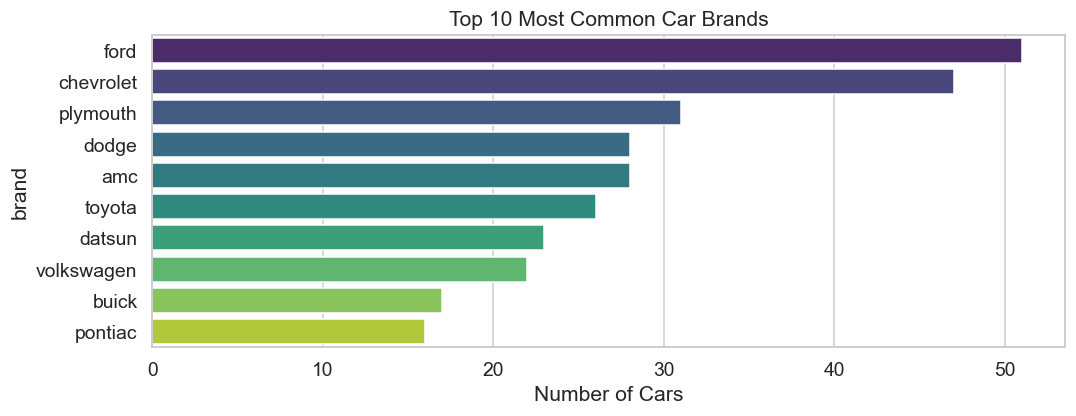

In [19]:
# Top-10 brands by car count
top_brands = df["brand"].value_counts().head(10)

plt.figure(figsize=(10, 4))
sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")
plt.title("Top 10 Most Common Car Brands")
plt.xlabel("Number of Cars")
plt.tight_layout()
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_8428\898487925.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_mpg.values, y=brand_mpg.index, palette="RdYlGn")


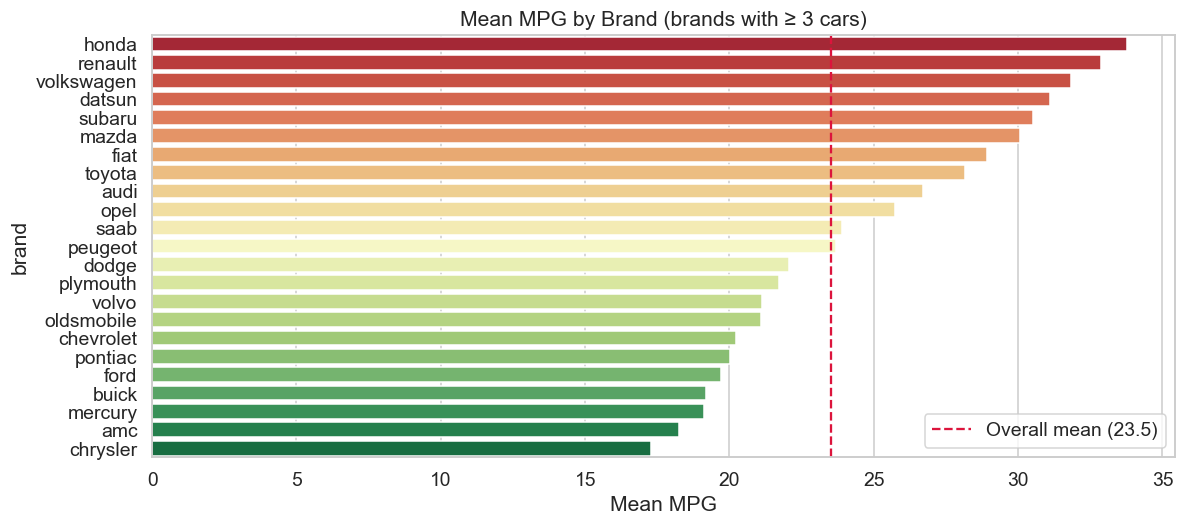

In [20]:
# Mean MPG per brand (min 3 cars to be reliable)
brand_counts = df["brand"].value_counts()
reliable_brands = brand_counts[brand_counts >= 3].index
brand_mpg = (df[df["brand"].isin(reliable_brands)]
             .groupby("brand")["mpg"]
             .mean()
             .sort_values(ascending=False))

plt.figure(figsize=(11, 5))
sns.barplot(x=brand_mpg.values, y=brand_mpg.index, palette="RdYlGn")
plt.axvline(df["mpg"].mean(), color="crimson", linestyle="--", label=f"Overall mean ({df['mpg'].mean():.1f})")
plt.legend()
plt.title("Mean MPG by Brand (brands with ≥ 3 cars)")
plt.xlabel("Mean MPG")
plt.tight_layout()
plt.show()


## 9. 🏷️ Aggregate Features & Target Encoding

These features encode **group statistics** back onto each row — a form of *target encoding*.

> ⚠️ In production, compute these statistics on the **training set only** to avoid data leakage.


In [21]:
# Brand-average MPG (target encoding)
brand_avg_mpg = df.groupby("brand")["mpg"].mean()
df["brand_avg_mpg"] = df["brand"].map(brand_avg_mpg)

# Binary flag: is this brand above the overall mean?
global_mean_mpg = df["mpg"].mean()
df["efficient_brand"] = (df["brand_avg_mpg"] > global_mean_mpg).astype(int)

# Brand popularity (count encoding)
df["brand_popularity"] = df["brand"].map(df["brand"].value_counts())

print(df[["name", "brand", "brand_avg_mpg", "efficient_brand", "brand_popularity"]].head(10))


                        name      brand  brand_avg_mpg  efficient_brand  \
0  chevrolet chevelle malibu  chevrolet      20.219149                0   
1          buick skylark 320      buick      19.182353                0   
2         plymouth satellite   plymouth      21.703226                0   
3              amc rebel sst        amc      18.246429                0   
4                ford torino       ford      19.694118                0   
5           ford galaxie 500       ford      19.694118                0   
6           chevrolet impala  chevrolet      20.219149                0   
7          plymouth fury iii   plymouth      21.703226                0   
8           pontiac catalina    pontiac      20.012500                0   
9         amc ambassador dpl        amc      18.246429                0   

   brand_popularity  
0                47  
1                17  
2                31  
3                28  
4                51  
5                51  
6                47 

C:\Users\hi\AppData\Local\Temp\ipykernel_8428\23136267.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="efficient_brand", y="mpg", palette=["tomato", "seagreen"], ax=axes[0])
C:\Users\hi\AppData\Local\Temp\ipykernel_8428\23136267.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Below Average Brand", "Above Average Brand"])


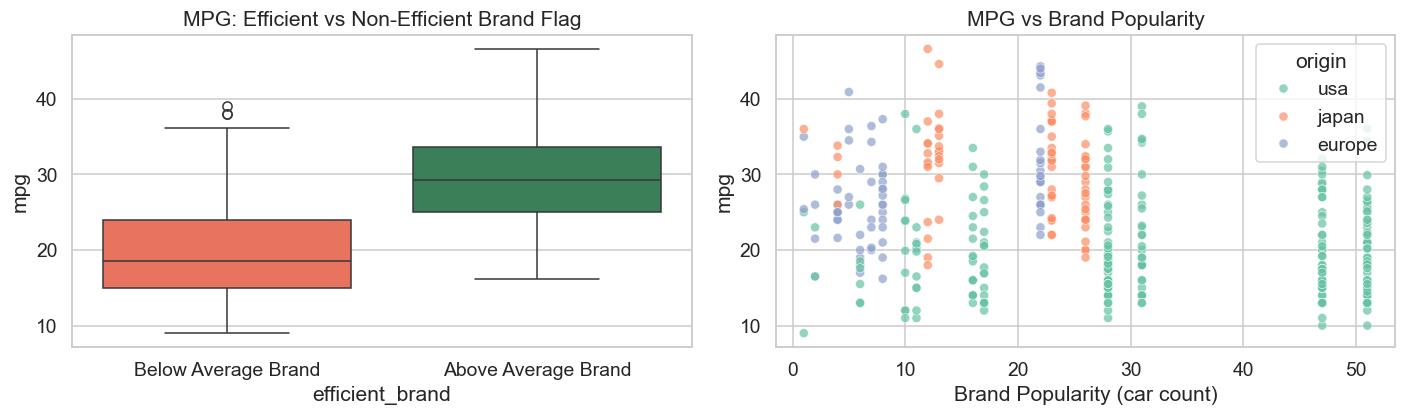

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Efficient vs non-efficient brand
sns.boxplot(data=df, x="efficient_brand", y="mpg", palette=["tomato", "seagreen"], ax=axes[0])
axes[0].set_xticklabels(["Below Average Brand", "Above Average Brand"])
axes[0].set_title("MPG: Efficient vs Non-Efficient Brand Flag")

# Brand popularity vs MPG
sns.scatterplot(data=df, x="brand_popularity", y="mpg", hue="origin",
                alpha=0.7, palette="Set2", ax=axes[1])
axes[1].set_title("MPG vs Brand Popularity")
axes[1].set_xlabel("Brand Popularity (car count)")

plt.tight_layout()
plt.show()


## 10. 🔗 Interaction Features

Multiplying or dividing two features creates a new variable that captures their **joint effect**.


In [23]:
df["hp_x_weight"]     = df["horsepower"] * df["weight"]         # raw "force" proxy
df["displ_x_accel"]   = df["displacement"] * df["acceleration"]  # engine-size × acceleration

print(df[["hp_x_weight", "displ_x_accel", "mpg"]].describe())


        hp_x_weight  displ_x_accel         mpg
count  3.980000e+02     398.000000  398.000000
mean   3.376731e+05    2855.331407   23.514573
std    2.189985e+05    1282.633793    7.815984
min    8.441000e+04     875.000000    9.000000
25%    1.740945e+05    1679.000000   17.500000
50%    2.598040e+05    2397.050000   23.000000
75%    4.463238e+05    4020.000000   29.000000
max    1.113975e+06    6650.000000   46.600000


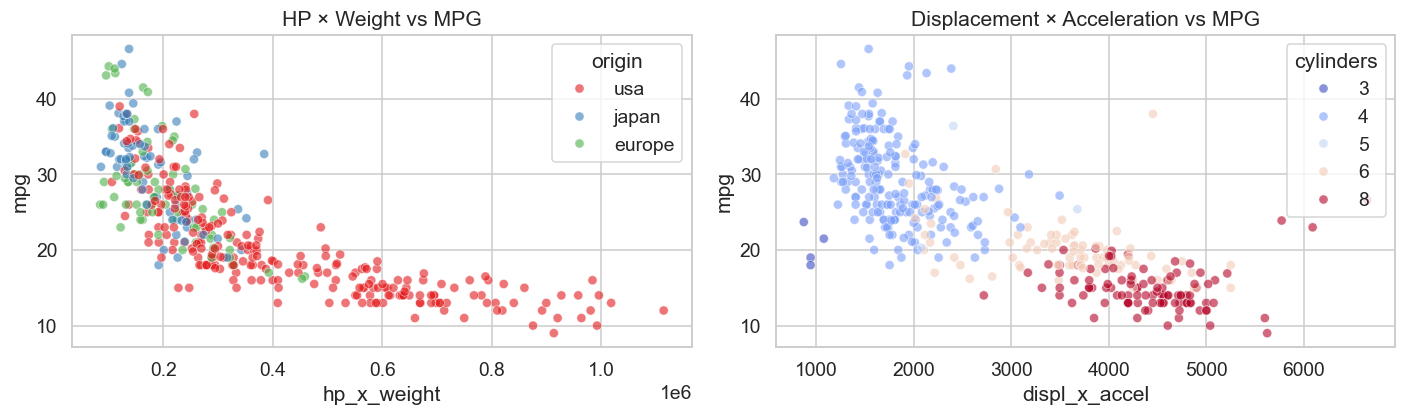

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(data=df, x="hp_x_weight", y="mpg", hue="origin",
                alpha=0.6, palette="Set1", ax=axes[0])
axes[0].set_title("HP × Weight vs MPG")

sns.scatterplot(data=df, x="displ_x_accel", y="mpg", hue="cylinders",
                alpha=0.6, palette="coolwarm", ax=axes[1])
axes[1].set_title("Displacement × Acceleration vs MPG")

plt.tight_layout()
plt.show()


## 11. 📐 Log Transformation

Skewed features can hurt linear models.  
Taking the natural log compresses large values and makes the distribution more Gaussian.


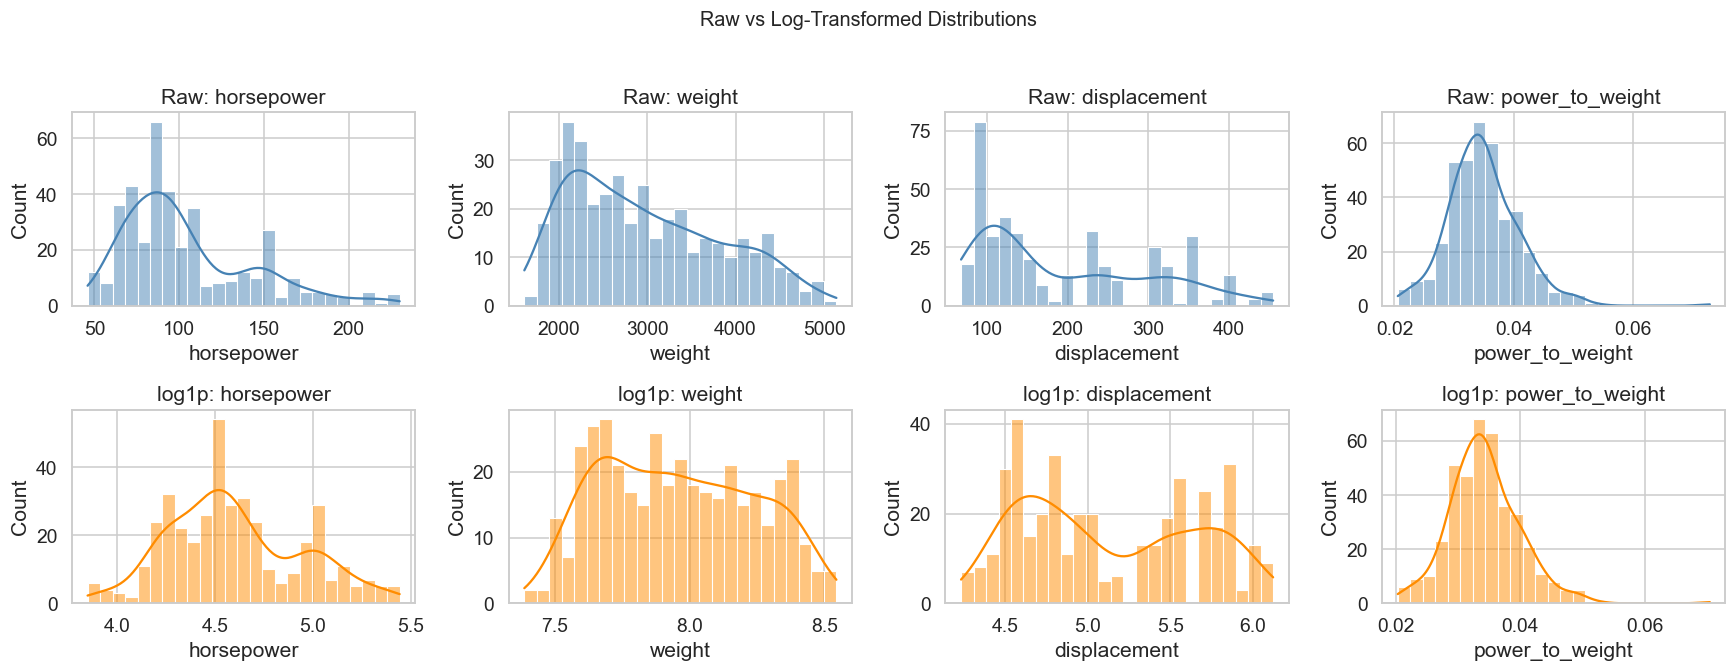

In [25]:
skewed_features = ["horsepower", "weight", "displacement", "power_to_weight"]

fig, axes = plt.subplots(2, len(skewed_features), figsize=(16, 6))

for i, col in enumerate(skewed_features):
    # Original
    sns.histplot(df[col], kde=True, ax=axes[0][i], color="steelblue", bins=25)
    axes[0][i].set_title(f"Raw: {col}")

    # Log
    log_col = np.log1p(df[col])
    sns.histplot(log_col, kde=True, ax=axes[1][i], color="darkorange", bins=25)
    axes[1][i].set_title(f"log1p: {col}")

plt.suptitle("Raw vs Log-Transformed Distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [26]:
# Add log-transformed versions to the DataFrame
for col in skewed_features:
    df[f"log_{col}"] = np.log1p(df[col])

print("Log features added:", [f"log_{c}" for c in skewed_features])


Log features added: ['log_horsepower', 'log_weight', 'log_displacement', 'log_power_to_weight']


## 12. 🔢 One-Hot Encoding

Machine learning models require **numeric inputs**.  
We one-hot encode the categorical features: `origin`, `weight_category`, `horsepower_bin`.


In [27]:
df_encoded = pd.get_dummies(
    df,
    columns=["origin", "weight_category", "horsepower_bin"],
    drop_first=False,    # keep all levels for interpretability
    dtype=int
)

new_ohe_cols = [c for c in df_encoded.columns if c not in df.columns]
print("New OHE columns:", new_ohe_cols)
df_encoded[new_ohe_cols].head(6)


New OHE columns: ['origin_europe', 'origin_japan', 'origin_usa', 'weight_category_light', 'weight_category_medium', 'weight_category_heavy', 'horsepower_bin_low', 'horsepower_bin_medium', 'horsepower_bin_high']


,origin_europe,origin_japan,origin_usa,weight_category_light,weight_category_medium,weight_category_heavy,horsepower_bin_low,horsepower_bin_medium,horsepower_bin_high
0,0,0,1,0,0,1,0,0,1
1,0,0,1,0,0,1,0,0,1
2,0,0,1,0,0,1,0,0,1
3,0,0,1,0,0,1,0,0,1
4,0,0,1,0,0,1,0,0,1
5,0,0,1,0,0,1,0,0,1


## 13. 📈 Correlation Analysis — Which Features Matter?

Now that we have many engineered features, let's see how they correlate with the **target (MPG)**.


In [28]:
# Only numeric columns in the encoded dataframe
numeric_encoded = df_encoded.select_dtypes(include=[np.number])
mpg_corr = numeric_encoded.corr()["mpg"].drop("mpg").sort_values(key=abs, ascending=False)

print("Top 20 features by |correlation| with MPG:")
print(mpg_corr.head(20).to_string())


Top 20 features by |correlation| with MPG:
log_weight               -0.843978
weight                   -0.831741
log_displacement         -0.828374
log_horsepower           -0.811160
displacement             -0.804203
accel_to_weight           0.797145
hp_x_weight              -0.785283
displ_x_accel            -0.776318
cylinders                -0.775396
horsepower               -0.773453
displacement_per_cyl     -0.773363
weight_category_heavy    -0.729799
horsepower_bin_low        0.678303
brand_avg_mpg             0.643271
horsepower_bin_high      -0.635610
efficient_brand           0.585036
car_age                  -0.579267
model_year                0.579267
origin_usa               -0.568192
weight_category_medium    0.448672


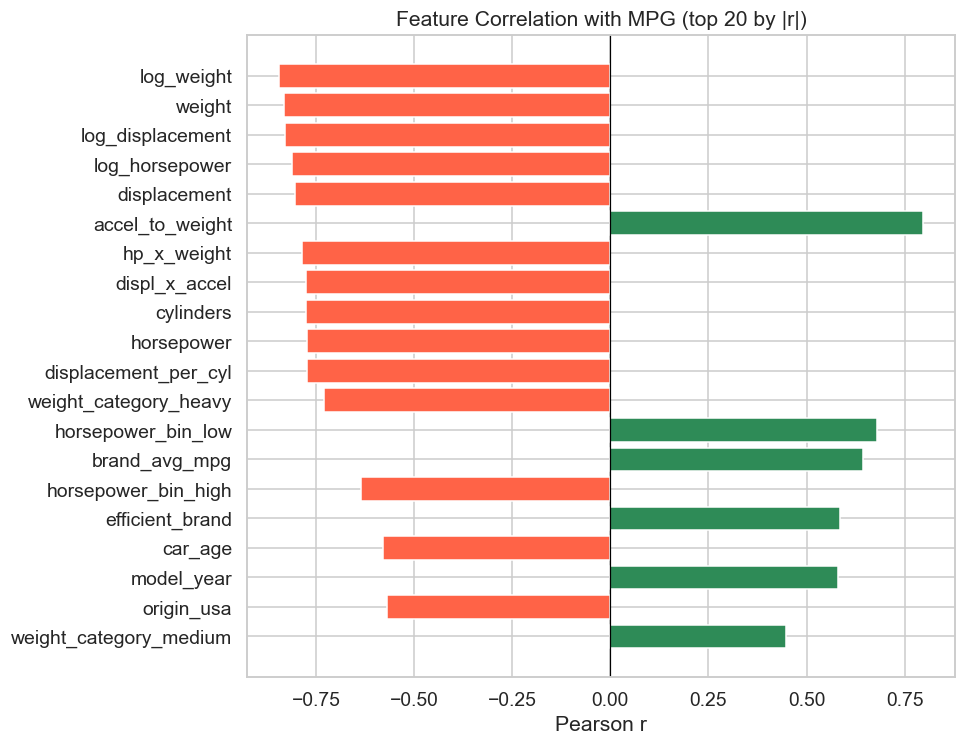

In [29]:
# Horizontal bar chart of top-20
top_corr = mpg_corr.head(20)
colors = ["seagreen" if v > 0 else "tomato" for v in top_corr.values]

plt.figure(figsize=(9, 7))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with MPG (top 20 by |r|)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()


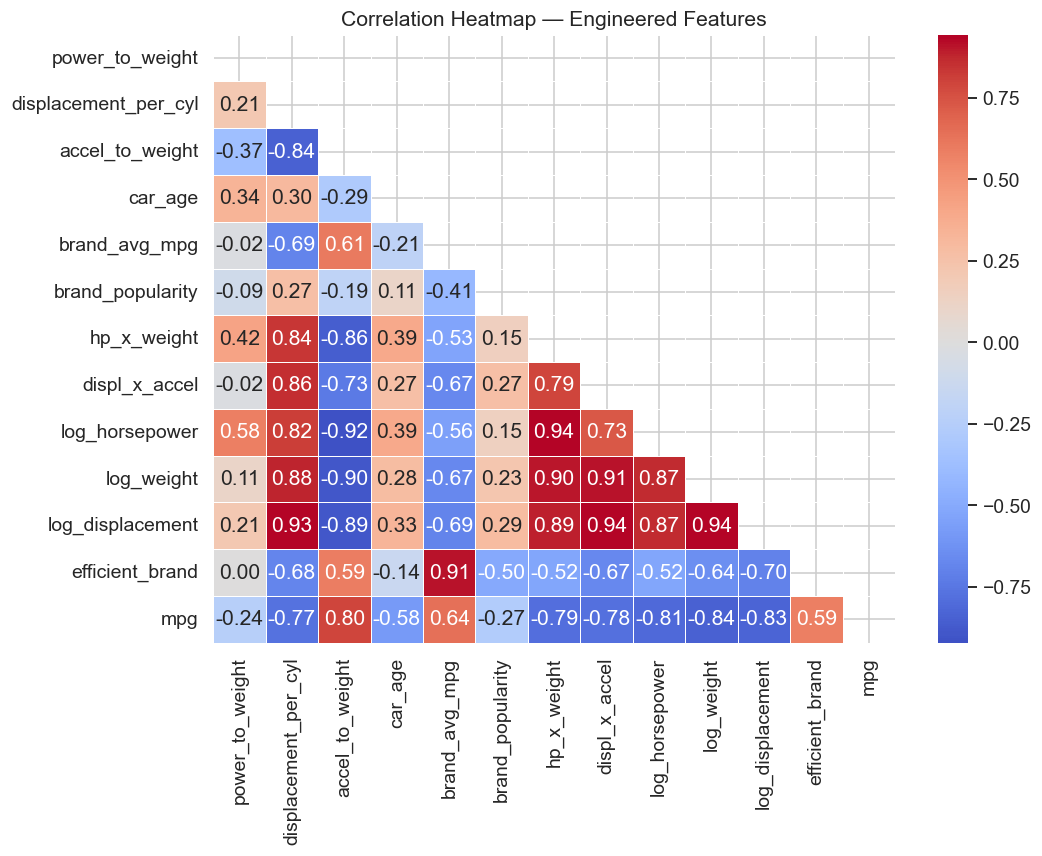

In [30]:
# Heatmap of engineered features vs MPG
eng_feats = [
    "power_to_weight", "displacement_per_cyl", "accel_to_weight",
    "car_age", "brand_avg_mpg", "brand_popularity",
    "hp_x_weight", "displ_x_accel",
    "log_horsepower", "log_weight", "log_displacement",
    "efficient_brand", "mpg"
]

plt.figure(figsize=(10, 8))
corr_eng = df_encoded[eng_feats].corr()
mask = np.triu(np.ones_like(corr_eng, dtype=bool))
sns.heatmap(corr_eng, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Engineered Features")
plt.tight_layout()
plt.show()


## 14. 📋 Final Feature Summary


In [31]:
print("Final DataFrame Shape:", df_encoded.shape)
print()
print("All Columns:")
for i, col in enumerate(df_encoded.columns, 1):
    print(f"  {i:>3}. {col}")


Final DataFrame Shape: (398, 31)

All Columns:
    1. mpg
    2. cylinders
    3. displacement
    4. horsepower
    5. weight
    6. acceleration
    7. model_year
    8. name
    9. power_to_weight
   10. displacement_per_cyl
   11. accel_to_weight
   12. car_age
   13. brand
   14. brand_avg_mpg
   15. efficient_brand
   16. brand_popularity
   17. hp_x_weight
   18. displ_x_accel
   19. log_horsepower
   20. log_weight
   21. log_displacement
   22. log_power_to_weight
   23. origin_europe
   24. origin_japan
   25. origin_usa
   26. weight_category_light
   27. weight_category_medium
   28. weight_category_heavy
   29. horsepower_bin_low
   30. horsepower_bin_medium
   31. horsepower_bin_high


In [32]:
df_encoded.head(5)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,name,power_to_weight,displacement_per_cyl,...,log_power_to_weight,origin_europe,origin_japan,origin_usa,weight_category_light,weight_category_medium,weight_category_heavy,horsepower_bin_low,horsepower_bin_medium,horsepower_bin_high
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu,0.037100,38.375,...,0.036429,0,0,1,0,0,1,0,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320,0.044679,43.750,...,0.043710,0,0,1,0,0,1,0,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite,0.043655,39.750,...,0.042729,0,0,1,0,0,1,0,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst,0.043694,38.000,...,0.042766,0,0,1,0,0,1,0,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino,0.040591,37.750,...,0.039789,0,0,1,0,0,1,0,0,1


---

## ✅ Summary of Feature Engineering Techniques Applied

| Technique | Features Created |
|---|---|
| **Ratio / Derived** | `power_to_weight`, `displacement_per_cyl`, `accel_to_weight` |
| **Uniform Binning** | `weight_category` |
| **Quantile Binning** | `horsepower_bin` |
| **Temporal** | `car_age` |
| **Text Extraction** | `brand` |
| **Target Encoding** | `brand_avg_mpg`, `efficient_brand` |
| **Count Encoding** | `brand_popularity` |
| **Interaction** | `hp_x_weight`, `displ_x_accel` |
| **Log Transform** | `log_horsepower`, `log_weight`, `log_displacement`, `log_power_to_weight` |
| **One-Hot Encoding** | `origin_*`, `weight_category_*`, `horsepower_bin_*` |

> **Next step:** Feed `df_encoded` (dropping `name`, `brand`, `mpg` as the target) into a model such as `sklearn`'s `RandomForestRegressor` or `GradientBoostingRegressor` and compare RMSE against baseline features only.
